In [8]:
# This code block turns off ligatures in the browser window (like where "ff" is written as a special character instead of two separate f's)
from IPython.core.display import HTML
HTML("""
    <style>
    body { font-feature-settings: "liga" 0; }
    </style>
""")

# Hot Shower
The objective of this demo is to illustrate how a parametric model can be constructed without data, and then subsequently linked to data sources in the cloud.

In the process, we will illustrate several features of LCA modeling in Antelope:
 - model construction with *observable* parameters
 - nesting and anchoring
 - linking
 - scenario-based LCIA


### Installation
You can install the tools required for this demo by running the following shell command:
```
$ pip install antelope-foreground antelope-reports
```
It is recommended to install python projects from within a virtual environment.

You may also be required to install `jupyter` and `ipython`, and to install an `ipykernel`, depending on your system.  Please see this link for more information: [iPython: Installing the IPython kernel](https://ipython.readthedocs.io/en/stable/install/kernel_install.html)

### Startup
In this step we create a [catalog](https://antelopelca.github.io/guidebook/catalog), which is the main organizing element of an Antelope session. Catalogs may be anchored to a specific directory on your computer, or they may be ephemeral, existing only for the current session.

In [1]:
from antelope_foreground import ForegroundCatalog
from antelope import enum


In [2]:
cat = ForegroundCatalog()

Loading JSON data from /data/GitHub/Antelope/core/antelope_core/archives/data/elcd_reference_quantities.json:
local.qdb: /data/GitHub/Antelope/core/antelope_core/archives/data/elcd_reference_quantities.json
local.qdb: Setting NSUUID (False) 77833297-6780-49bf-a61a-0cb707dce700
local.qdb: /data/GitHub/lca-tools/lcatools/qdb/data/elcd_reference_quantities.json
29 total quantity entities added (29 new)
6 total flow entities added (6 new)


The `show_interfaces()` command shows what data resources are attached to the catalog. Data access is organized around six different 
[interfaces](https://antelopelca.github.io/guidebook/interfaces/) which divide up different kinds of knowledge and information about LCA.

In [3]:
cat.show_interfaces()

local.qdb [basic, index, quantity]


# Create the demo Foreground

In [4]:
fg = cat.create_foreground('demo')
cat.show_interfaces()

QQQQQQQQQQQQQQQQQQ demo QQQQQQQQQQQQQQQQQQ
Found Antelope providers:
AntelopeMeta:_dev
antelope_core.providers:IlcdArchive
antelope_core.providers:IlcdLcia
antelope_core.providers:EcospoldV2Archive
antelope_core.providers:EcospoldV1Archive
antelope_core.providers:EcoinventLcia
antelope_core.providers:OpenLcaJsonLdArchive
antelope_core.providers:Traci21Factors
antelope_core.providers:XdbClient
antelope_core.providers:OpenLcaRefData
antelope_background.providers:TarjanBackground
antelope_background.providers:Background
antelope_foreground.providers:AntelopeV1Client
antelope_foreground.providers:LcForeground
antelope_foreground.providers:OryxClient
demo: demo
demo: Setting NSUUID (None) None
Loading demo
0 total fragment entities added (0 new)
demo [basic, foreground, index, quantity]
local.qdb [basic, index, quantity]


`QuickAndEasy` is a convenience tool for creating foregrounds easily. It is part of the `antelope_reports` package.

In [5]:
from antelope_reports import QuickAndEasy

In [6]:
Q = QuickAndEasy(fg)

The **`new_link()`** function creates a new fragment link that includes three required arguments:
 - a flow, specified by name
 - a reference quantity for that flow
 - a direction for that flow. If the flow is a reference flow, specify the flow's direction from the node's perspective ('Output' is standard). If the flow is a child flow, specify the direction with respect to the parent (e.g. electricity would be an 'Input' but a co-product would be an 'Output')

If the flow is a child flow, you must specify:
 - parent, the node whose activity drives the flow.

The following optional parameters can also be specified:
 - amount (numeric exchange value for the flow)
 - units (default to the reference quantity's unit)
 - balance=True (tells the flow's magnitude to be calculated at traversal time by balancing the reference quantity) 
 - name (what to name the fragment, defaults to the flow name)
 - stage (how the fragment's impacts should be grouped in LCIA)

Only child flows can be balance flows.  If you specify balance=True, it is an error to also specify an amount. Note that you can also specify direction='balance' because the direction of the flow will be determined based on the balance.

Now we are ready to build the model.

## Step 1- the shower
First thing you do in the morning is take a shower, right? How do we want to parameterize this activity?
 - Duration of shower
 - Water flow rate
 - temperature of water
 - efficiency of heater
 - ... soap?

We start by pulling some reference quantities from the catalog to use to specify our flows.  These can be grabbed by canonical name or synonym. 

In [33]:
volume = cat.get_canonical('volume')
mass = cat.get_canonical('mass')
ncv = cat.get_canonical('net calorific value')

In [9]:
list(cat.synonyms('mass'))

['93a60a56-a3c8-11da-a746-0800200b9a66',
 'EcoSpold Quantity kg',
 'Mass',
 'Mass [kg]',
 '[local.qdb] Mass [kg]',
 'elcd.3.2/93a60a56-a3c8-11da-a746-0800200b9a66',
 'flowproperties/93a60a56-a3c8-11da-a746-0800200b9a66',
 'local.qdb/93a60a56-a3c8-11da-a746-0800200b9a66']

We can list all available quantities in the catalog. Note the use of the nonstandard `enum` function, which is a helper function included in Antelope which is very useful for interactive selection of a specific item from a list. All it does is print the entries of a list, prefixed with their index.

In [11]:
_=enum(cat.lcia_engine.quantities())

 [00] [local.qdb] Area [m2]
 [01] [local.qdb] Area*time [m2*a]
 [02] [local.qdb] Carbon content (biogenic) [kg]
 [03] [local.qdb] Carbon content (fossil) [kg]
 [04] [local.qdb] Contribution Analysis (percent) [percent] [LCIA]
 [05] [local.qdb] Contribution Analysis [share] [LCIA]
 [06] [local.qdb] Duration [a]
 [07] [local.qdb] Electric energy [kWh]
 [08] [local.qdb] Energy from renewable raw materials (net cal. value) [MJ] [LCIA]
 [09] [local.qdb] Energy renewable and non renewable (gross calorific value) [MJ] [LCIA]
 [10] [local.qdb] Energy renewable and non renewable (net calorific value) [MJ] [LCIA]
 [11] [local.qdb] Exergy [MJ]
 [12] [local.qdb] Goods transport (mass*distance) [t*km]
 [13] [local.qdb] Gross calorific value [MJ]
 [14] [local.qdb] Hydrogen content (mass) [kg]
 [15] [local.qdb] Length [m]
 [16] [local.qdb] Market value US 2000, bulk prices [EUR]
 [17] [local.qdb] Mass [kg]
 [18] [local.qdb] Net calorific value [MJ]
 [19] [local.qdb] Node Activity [activity]
 [20] [lo

We're ready to create our reference fragment: one (1) shower. When `new_link()` creates a new reference fragment, it also assigns it a name automatically.

In [10]:
shower = Q.new_link('hot shower', 'Count', 'Output')

Naming fragment 61f66ba3-9aca-45a2-81be-e1e3bf72d1a9 -> hot_shower


You can store the fragment in a local variable, like above, or retrieve it by its name or its uuid, using `fg.__getitem__`

In [14]:
assert shower is fg['hot_shower']
assert shower is fg[shower.uuid]

### Trees
A fragment is essentially a tree. The reference flow emanates from the root node of the tree. Each node can have child flows, and each child flow has its own node that can have further child flows.  The `show_tree()` function draws the fragment tree in a cheesy little ASCII-art diagram.  Reading the diagram takes some practice, but here are the key elements:

Each line (roughly) corresponds to a fragment in the tree. For instance, the hot shower fragment might look like this:

` -<---:   61f66 [       1 Item(s)] hot shower`

 * `-<--` or `=>==` indicate the direction of the flow relative to the node. This flow is an output.
 * The node itself can be:
 *  `-:` (cutoff, no actual node)
 *  `O` (foreground node with child flows)
 *  `*` (foreground node anchored to a database process)
 *  `#` (foreground node anchored to a sub-fragment)
 *  `61f66` the first 5 characters of the fragment's UUID, which can be used to retrieve the fragment easily. This value will be different for every user because a fragment's UUID is chosen at random when the fragment is created.
 *  `[      1 Item(s) ]` the exchange value of the fragment
 *  `hot shower` the fragment's flow 



Now we add child flows to the fragment. Notice how we specify the "parent" node in each case, as well as an amount. Notice also how we are using the general-purpose "Count" quantity to represent the number of minutes, rather than a quantity that corresponds to actual duration. This is mostly because the default quantity for duration has "year" as its average unit, and I did not want to specify my shower length as a fraction of a year.

In [12]:
water_min = Q.new_link('duration of shower (minutes)', 'Count', 'Input', parent=shower, amount=15)
soap = Q.new_link('soap', 'volume', 'Input', parent=shower, amount=3, units='mL')

Now, if we show the tree, we will see the reference flow has child flows:

In [15]:
shower.show_tree()

   -<--O   61f66 [       1 Item(s)] hot shower
    [   1 unit] hot shower
       | -<----: 26b59 [       1 Item(s)] duration of shower (minutes)
       | -<----: 86357 [       1 m3] soap
       x 


But hold on! didn't we specify 3 mL of soap? Why is it showing a cubic meter of soap?

That is because the default fragment is **data-free**. The default view shows only the structure of the fragment, with unit magnitudes for every flow. The information is in there, but it's not reported by default.  When we specify an exchange value for a fragment, this is called **observing** the fragment.  To see the observed exchange value, we need to specify `show_tree(observed=True)`

In [16]:
shower.show_tree(observed=True)

   -<--O   61f66 [       1 Item(s)] hot shower
    [   1 unit] hot shower
       | -<----: 26b59 [      15 Item(s)] duration of shower (minutes)
       | -<----: 86357 [   3e-06 m3] soap
       x 


### Oops I accidentally created an extra link

In [17]:
l = Q.new_link('soap', 'volume', 'Input', parent=shower, amount=3, units='mL')

In [18]:
shower.show_tree()

   -<--O   61f66 [       1 Item(s)] hot shower
    [   1 unit] hot shower
       | -<----: 26b59 [       1 Item(s)] duration of shower (minutes)
       | -<----: 86357 [       1 m3] soap
       | -<----: cd1c5 [       1 m3] soap
       x 


No problem, just delete it!  You can use the `fg.frag()` command to retrieve a fragment by its fractional UUID. Note that the UUID is selected randomly, so the `frag()` function only works when you can see and identify the fragment you want to delete.

In this demo case, the extra bar of soap has the UUID `cd1c5.....`. The `frag()` function only requires you to specify enough of the UUID to identify the fragment distinctly. Since our foreground has only 4 fragments at the moment, it's pretty likely that two characters is enough.

In [19]:
fg.delete_fragment(fg.frag('cd'))

True

In [20]:
shower.show_tree()

   -<--O   61f66 [       1 Item(s)] hot shower
    [   1 unit] hot shower
       | -<----: 26b59 [       1 Item(s)] duration of shower (minutes)
       | -<----: 86357 [       1 m3] soap
       x 


### Building the water supply
Now let's model the water supply. We have two things going on here: an amount of water that we need, and an amount of thermal energy needed to heat the water. We will model those separately using sequential fragments. First, we will transform our shower *duration* in minutes to an amount using a "flow rate per minute" fragment. That amount will then drive two child fragments- one to provide the water, and the other to provide the heat.  

To model the heat requirements, we'll multiply the water volume by a temperature increase, and then by a static value that equals the heat capacity of water.  When the fragment is traversed, all these values get multiplied together, so we end up implementing the classic equation:

 $ Q = c*m*\Delta T$

where *m* is actually $\dot{q}*t$, the flow rate times the duration.

In [21]:
water_vol = Q.new_link('Flow rate per minute', 'volume', 'Input', parent=water_min, amount=2, units='gal')

In [22]:
water_supply = Q.new_link('water supply', 'volume', 'Input', balance=True, parent=water_vol)
temp_increase = Q.new_link('temperature increase degrees C', 'Count', 'Input', parent=water_vol, amount=40)
heat_input = Q.new_link('heat input required', 'net calorific value', 'Input', parent=temp_increase, amount=4.184, units='MJ')

At this point, our tree is getting to be fairly elaborate, but it still expresses the structure of the model pretty clearly if you know how to read it:

In [23]:
shower.show_tree(observed=True)

   -<--O   61f66 [       1 Item(s)] hot shower
    [   1 unit] hot shower
       | -<----: 86357 [   3e-06 m3] soap
       | -<--O   26b59 [      15 Item(s)] duration of shower (minutes)
       |  [   1 unit] duration of shower (minutes)
       |     | -<--O   73474 [ 0.00757 m3] Flow rate per minute
       |     |  [   1 unit] Flow rate per minute
       |     |     | -<--O   539c7 [      40 Item(s)] temperature increase degrees C
       |     |     |  [   1 unit] temperature increase degrees C
       |     |     |     | -<----: 6959f [    4.18 MJ] heat input required
       |     |     |     x 
       |     |     x 
       |     x 
       x 


### Run the model

At this point we can actually run the model (traverse the fragment).  Traversing the fragment returns a list of `FragmentFlow` objects -- these are fragments that are encountered during the traversal, with their node weights and flow magnitudes computed at traversal time.

There are three different ways to view this information:
 1. We can `traverse` the tree, which returns the full list of fragment flows 
 2. node `activity` - which is nodes inside the fragment that get activated.
 3. `cutoffs` - which are flows that enter or leave the fragment's boundary.

The list of fragment flows generated during traversal is partitioned into active nodes and cutoffs. So item 1 is the union of items 2 and 3.

In [24]:
_=enum(shower.traverse())

 [00] 61f66           1 [ Input] -O   hot_shower
 [01] 26b59           1 [ Input] -O   duration of shower (minutes)
 [02] 73474           1 [ Input] -O   Flow rate per minute
 [03] 539c7           1 [ Input] -O   temperature increase degrees C
 [04] 6959f           1 [ Input] ---: heat input required
 [05] 0b6c6           1 [ Input] ---: water supply
 [06] 86357           1 [ Input] ---: soap


Remember to specify `observed` flows if you want to see the actual data. As a shortcut, you can just specify `True` as the first argument, without having to write the "observed" keyword.

The active nodes are shown reporting *node weights*, and the cutoffs are shown reporting *flow magnitudes*.

In [25]:
_=enum(shower.traverse(True))

 [00] 61f66           1 [ Input] -O   hot_shower
 [01] 26b59          15 [ Input] -O   duration of shower (minutes)
 [02] 73474       0.114 [ Input] -O   Flow rate per minute
 [03] 539c7        4.54 [ Input] -O   temperature increase degrees C
 [04] 6959f          19 [ Input] ---: heat input required
 [05] 0b6c6       0.114 [ Input] ---: water supply
 [06] 86357       3e-06 [ Input] ---: soap


When `cutoffs` is run, an additional entry is added for the reference flow, which otherwise does not show up in the traversal:

In [26]:
_=enum(shower.cutoffs(observed=True))

 [00] [ hot_shower ] <--  19 (MJ) heat input required  (cutoff)
 [01] [ hot_shower ] <--  0.114 (m3) water supply  (cutoff)
 [02] [ hot_shower ] <--  3e-06 (m3) soap  (cutoff)
 [03] [ hot_shower ]*==>  1 (Item(s)) hot shower 


### Drawing the fragment graph
The `pydot` package can be used to draw the fragment as a graph.

In [27]:
from antelope_reports.charts.model_graph import ModelGraph

In [28]:
g = ModelGraph(shower)

The `display()` function doesn't actually do anything- it just prints instructions to the user about how to display the graph.

In [29]:
g.display()

# To display a model graph in a jupyter notebook environment, run the following
from IPython.display import Image, display

%matplotlib inline  # add if using jupyter

def view_pydot(pdot):
    plt = Image(pdot.graph.create_png())
    display(plt)
            
view_pydot(mg.graph)  # mg is a ModelGraph instance



In [30]:
from IPython.display import Image, display

# add if using jupyter
%matplotlib inline  

def view_pydot(pdot):
    plt = Image(pdot.graph.create_png())
    display(plt)

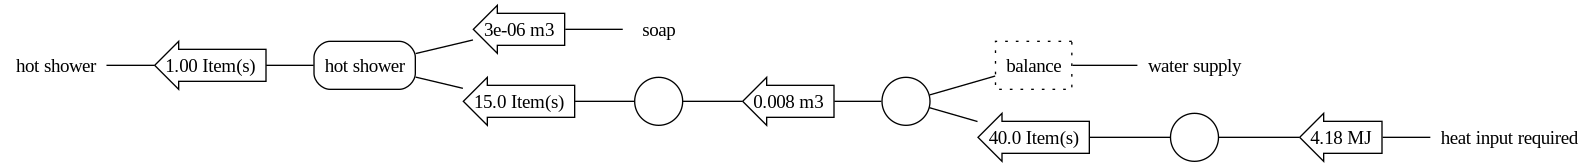

In [31]:
view_pydot(g)

## Heat provisioning
Right now we have a model with three cut-off flows: soap, water, and heat.  Of those, the heat is the most complex and likely the most impactful.  Let's make a couple of different heat provisioning models, one with natural gas and the other with electricity.


For our first heat source, we'll use natural gas. We want to account for the efficiency of the heating system, so we'll create a tree that outputs 0.65 MJ of heat for every 1 MJ of heat in.  We use the `observe()` function to specify the exchange value for the reference flow:

In [35]:
heat_ng = Q.new_link('Heat from natural gas', ncv, 'Output')
fg.observe(heat_ng, exchange_value=0.65)
heat_in = Q.new_link('Heat combustion', ncv, 'Input', parent=heat_ng, amount=1.0)

Naming fragment 1b11cdb0-f7d3-45db-979f-177934d59d33 -> heat_from_natural_gas


`fg.observe()` is a multi-purpose function whose role is to allow the modeler to specify *all aspects* of the model's behavior under different circumstances. It accepts many different arguments:

 - `fragment` (the only required argument, which fragment is being observed)
 - `exchange_value` - specify the exchange value
 - `anchor_node` - specify what the node should be anchored to (background process, another fragment, an environmental context, or `None` to create a cutoff fragment)

The `observe()` function is also used to assign names and to specify scenarios (about which more later) 

In [36]:
heat_ng.show_tree(True)

   -<--O   1b11c [*   0.65 MJ] Heat from natural gas
    [   1 unit] Heat from natural gas
       | -<----: 7dd16 [       1 MJ] Heat combustion
       x 


Now we'll make an electricity model, and assume 90% efficiency.

In [37]:
heat_elec = Q.new_link('Heat from electricity', ncv, 'Output')
fg.observe(heat_elec, exchange_value=0.9)
heat_in_e = Q.new_link('Heat in from electricity', ncv, 'Input', parent=heat_elec, amount=1.0)


Naming fragment a858904f-5efd-450b-993c-779fb91c03a6 -> heat_from_electricity


In [38]:
heat_elec.show_tree(observed=True)

   -<--O   a8589 [     0.9 MJ] Heat from electricity
    [   1 unit] Heat from electricity
       | -<----: 97777 [       1 MJ] Heat in from electricity
       x 


### Attach the heat supplies to the model

Now we will attach our heat supplies to the model by "anchoring" the heat input to our heat supplies. To perform the anchoring, we use the `observe()` function again, this time specifying two different scenarios.  We will create one called 'natural gas' which uses the natural gas heater, and one called 'electric' which uses the electric heater.



In [41]:
fg.observe(heat_input, anchor_node=heat_ng, scenario='natural gas')
fg.observe(heat_input, anchor_node=heat_elec, scenario='electric')

'demo/6959f1f0-8064-46e9-af1f-37ddf9ae8ac2'

We can see the fragment now knows about the scenarios:

In [42]:
list(shower.scenarios())

['electric', 'natural gas']

The scenario name is the actual first argument of the traversal functions, but `True` works by default. 

In [44]:
shower.show_tree('natural gas')

   -<--O   61f66 [       1 Item(s)] hot shower
    [   1 unit] hot shower
       | -<----: 86357 [*  3e-06 m3] soap
       | -<--O   26b59 [*     15 Item(s)] duration of shower (minutes)
       |  [   1 unit] duration of shower (minutes)
       |     | -<--O   73474 [*0.00757 m3] Flow rate per minute
       |     |  [   1 unit] Flow rate per minute
       |     |     | -<----: 0b6c6 (=      0 m3) water supply
       |     |     | -<--O   539c7 [*     40 Item(s)] temperature increase degrees C
       |     |     |  [   1 unit] temperature increase degrees C
       |     |     |     | -<--#:: 6959f [%   4.18 MJ] heat input required
       |     |     |     x 
       |     |     x 
       |     x 
       x 


In [46]:
_=enum(shower.cutoffs('natural gas'))

 [00] [ hot_shower ] <--  29.2 (MJ) Heat combustion  (cutoff)
 [01] [ hot_shower ] <--  0.114 (m3) water supply  (cutoff)
 [02] [ hot_shower ] <--  3e-06 (m3) soap  (cutoff)
 [03] [ hot_shower ]*==>  1 (Item(s)) hot shower 


Now, when we draw the model graph and we specify one of our scenarios, it will show that the heat input is anchored to another fragment.

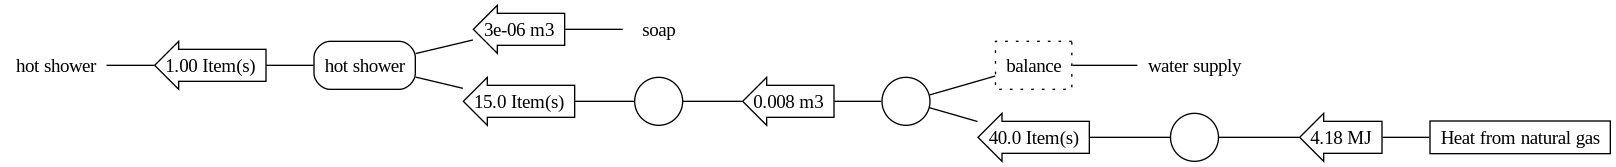

In [47]:
g = ModelGraph(shower, scenario='natural gas')
view_pydot(g)

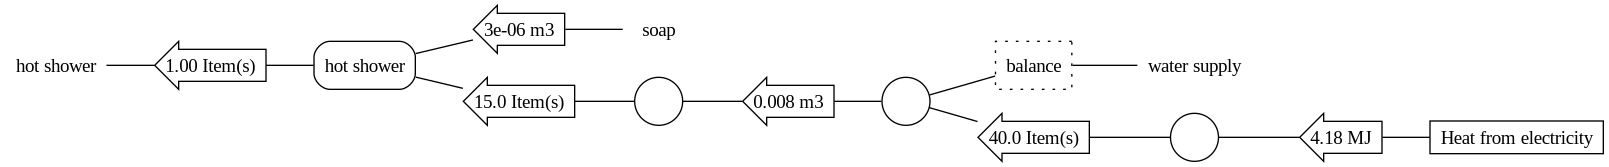

In [48]:
g = ModelGraph(shower, scenario='electric')
view_pydot(g)

# Linking the model

So now we have a data-free model that describes the foreground activity of taking a shower.  It includes embedded assumptions about how much water we use, how much heat we require, and about the efficiencies of the heating system. The only thing missing is the actual background data!  We need to fill this model out with details about the supply of the products and resources we require.  In Antelope terms, we need to anchor our cutoff flows.

To do that, we'll use data sets from the Federal LCA Commons.  We will access the free version of the US LCI database available from Antelope's cloud platform, which is hosted at [https://vault.lc](https://vault.lc)

For the moment, we can access these resources without even registering, by using the guest feature.

In [51]:
cat.blackbook_guest('https://sc.vault.lc')

GET https://sc.vault.lc/auth/guest.. 200 [0.48 sec]
Welcome 'Guest user' to blackbook, courtesy of ANTELOPE_AUTHORITY.
You are accessing from IP 47.141.36.189
Last access: Mon Mar 23 17:45:37 2026 


`vault.lc` provides a limited but useful set of resources for free to guest users:

In [40]:
list(cat.blackbook_origins)

GET https://sc.vault.lc/origins.. 200 [0.14 sec]


['lcacommons.fhwa.asphaltframework',
 'lcacommons.useeio.2.0.1',
 'lcacommons.uslci.fy21.q1',
 'lcacommons.uslci.fy22.q3',
 'lcacommons.uslci.fy22.q4.01',
 'lcacommons.uslci.fy23.q4',
 'lcacommons.uslci.fy24.q1.01',
 'lcia.openlca.2.1.4',
 'lcia.openlca.2.7.5',
 'lcia.traci.2.1']

We simply have to request the resource:

In [52]:
r = cat.get_blackbook_resources('lcacommons.uslci.fy24.q1.01')[0]

GET https://sc.vault.lc/origins/lcacommons.uslci.fy24.q1.01/resource.. 200 [1.04 sec]


And now we have access to it in our catalog:

In [53]:
cat.show_interfaces()

demo [basic, foreground, index, quantity]
lcacommons.uslci.fy24.q1.01 [background, basic, exchange, index]
local.qdb [basic, index, quantity]


We can delete it, if something went wrong:

In [ ]:
cat.delete_resource(r)

## Database Queries

Now we are going to access the resource to find suitable LCI data for our shower model.  To do this we create a [query](https://antelopelca.github.io/guidebook/using-lca-data):

In [54]:
q_us = cat.query('lcacommons.uslci.fy24.q1.01')

QQQQQQQQQQQQQQQQQQ lcacommons.uslci.fy24.q1.01 QQQQQQQQQQQQQQQQQQ
GET https://bk.vault.lc/origins.. 200 [0.21 sec]
lcacommons.uslci.fy24.q1.01: https://bk.vault.lc/
lcacommons.uslci.fy24.q1.01: Setting NSUUID (False) None
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/config.. 200 [0.05 sec]
Applying configuration to XdbClient with 0 entities at https://bk.vault.lc/


Our main workflow here is as follows:
 1. Find a flow we are interested in
 2. Find processes that provide that flow
 3. Select a suitable process and "anchor" it to our model using `observe()`

First, we find natural gas flows:

In [56]:
ngs = enum(q_us.flows(name='natural gas'))

GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/flows.. 200 [0.10 sec]
 [00] [lcacommons.uslci.fy24.q1.01] Transport, pipeline, natural gas [t*km]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/f6811440-ee37-11de-8a39-0800200c9a66.. 200 [0.05 sec]
 [01] [lcacommons.uslci.fy24.q1.01] Natural gas, 16% shale blend, at consumer  [MJ]
 [02] [lcacommons.uslci.fy24.q1.01] Natural gas, production mixture, at processing [kg]
 [03] [lcacommons.uslci.fy24.q1.01] Natural gas, production mixture, to energy use [kg]
 [04] [lcacommons.uslci.fy24.q1.01] Natural gas, at processing, shale, kg [kg]
 [05] [lcacommons.uslci.fy24.q1.01] Natural gas, combusted in industrial boiler, at hydrocracker, for butadiene [m3]
 [06] [lcacommons.uslci.fy24.q1.01] Natural gas, at processing, conventional, kg [kg]
 [07] [lcacommons.uslci.fy24.q1.01] Natural gas, combusted in industrial boiler, at hydrocracker, for propylene [m3]
 [08] [lcacommons.uslci.fy24.q1.01] Natural gas [MJ]
 [09] [lcacommons.uslci.fy24.q1

I happen to like `Natural gas, combusted in indusrial boiler`, so I will select it.

In [57]:
ng = ngs[16]

Now, we find `targets` for this flow, which are processes that list it as a reference:

In [58]:
tgts = enum(ng.targets())

GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/ea8515c5-e3d4-4f42-a856-67a9b85b30a0/targets.. 200 [0.06 sec]
 [00] [lcacommons.uslci.fy24.q1.01] Natural gas, combusted in industrial boiler [Northern America]


There's only one, so we use it.

In [59]:
n = tgts[0]
str(n.reference())

'[ Natural gas, combusted in industrial boiler [Northern America] ]*==>  0 (m3) Natural gas, combusted in industrial boiler '

In [60]:
heat_ng.show_tree()

   -<--O   1b11c [       1 MJ] Heat from natural gas
    [   1 unit] Heat from natural gas
       | -<----: 7dd16 [       1 MJ] Heat combustion
       x 


In [61]:
fg.observe(heat_in, anchor_node=n)

'demo/7dd1650d-e746-4332-a71e-2489339c2403'


Ah, but there's a subtle problem: our model is expecting heat in MJ, but the process we selected is measured in cubic meters. If we tried to traverse the model now, we would generate an error:

In [62]:
heat_ng.traverse()

GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/2213: Water, Sewage and Other Systems.. 200 [0.06 sec]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/22: Utilities.. 200 [0.05 sec]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/Technosphere Flows.. 200 [0.05 sec]
 demo/7dd1650d-e746-4332-a71e-2489339c2403: flow_conversion: untested
 demo/7dd1650d-e746-4332-a71e-2489339c2403: flow_conversion FAILED


FlowConversionError: Zero CF found relating [lcacommons.uslci.fy24.q1.01] Natural gas, combusted in industrial boiler [m3] to [demo] Heat combustion [MJ]


### Flow Characterization

The solution is to simply specify a conversion factor between m3 and MJ for our desired flow.  (We could also accomplish this by introducing an intermediary fragment that performs the conversion, the way we built the shower model)


In [63]:
help(heat_in.flow.characterize)

Help on method characterize in module antelope.refs.flow_ref:

characterize(quantity, value, context=None, location='GLO', origin=None, **kwargs) method of antelope.refs.flow_ref.FlowRef instance



We are going to use two factors I found on the internet, that say:
 1. natural gas has a heating value of 52 MJ/kg
 2. natural gas has a density of 1.357 m3/kg
 3. Therefore Our characterization is 1.357/52 m3 per MJ

In [64]:
heat_in.flow.characterize('volume', 1.357/52)  # m3 per MJ

Characterization(demo/flow_heat_combustion, MJ, None: 0.0261 (m3))

Now, our traversal should not fail:

In [65]:
heat_ng.traverse()

In [66]:
heat_ng.show_tree(True)

   -<--O   1b11c [*   0.65 MJ] Heat from natural gas
    [   1 unit] Heat from natural gas
       |        Stage: Natural gas, combusted in industrial boiler
       | -<--B*  7dd16 [       1 MJ] Heat combustion
       x 


In [53]:
ffs=enum(heat_ng.traverse(True))

 [00] cccc6        0.65 [ Input] -O   heat_from_natural_gas
 [01] 3163d           1 [ Input] -B*  Natural gas, combusted in industrial boiler [Northern America]


Now we have succeeded in anchoring one of our crucial cutoff flows! When we look at the model under the `natural gas` scenario, we will no longer see the heat requirement as a cutoff:

In [67]:
_=enum(shower.cutoffs('natural gas'))

 [00] [ hot_shower ] <--  0.114 (m3) water supply  (cutoff)
 [01] [ hot_shower ] <--  3e-06 (m3) soap  (cutoff)
 [02] [ hot_shower ]*==>  1 (Item(s)) hot shower 


_=enum(shower.cutoffs('natural gas'))It is still there for electricity, however:

In [68]:
_=enum(shower.cutoffs('electric'))

 [00] [ hot_shower ] <--  21.1 (MJ) Heat in from electricity  (cutoff)
 [01] [ hot_shower ] <--  0.114 (m3) water supply  (cutoff)
 [02] [ hot_shower ] <--  3e-06 (m3) soap  (cutoff)
 [03] [ hot_shower ]*==>  1 (Item(s)) hot shower 


So, we use the same procedure to select an electric grid:

In [70]:
elecs = enum(q_us.processes(name='electricity, at grid'))

GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/processes.. 200 [0.12 sec]
 [00] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, MRO, 2008 [Northern America]
 [01] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, RFC, 2008 [Northern America]
 [02] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, RFC, 2010 [Northern America]
 [03] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, TRE, 2010 [Northern America]
 [04] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, FRCC, 2008 [Northern America]
 [05] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, NPCC, 2010 [Northern America]
 [06] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, HICC, 2010 [Northern America]
 [07] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, NPCC, 2008 [Northern America]
 [08] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, FRCC, 2010 [Northern America]
 [09] [lcacommons.uslci.fy24.q1.01] Electricity, at Grid, TRE, 2008 [Northern America]
 [10] [lcacommons.uslci.fy24.q1.01] Electricit

In [71]:
elec = elecs[20]
elec.show()
str(elec.reference())

ProcessRef catalog reference (c6fe7799-8cb7-32e6-9bd9-a3d5564c218f)
origin: lcacommons.uslci.fy24.q1.01
   UUID: c6fe7799-8cb7-32e6-9bd9-a3d5564c218f
   Name: Electricity, at Grid, MRO, 2010
Comment: 
==Local Fields==
     SpatialScope: Northern America
    TemporalScope: {'begin': '2009-12-31', 'end': '2009-12-31'}
  Classifications: ['22: Utilities', '2211: Electric Power Generation, Transmission and Distribution']
 blackbook_origin: lcacommons.uslci.fy24.q1.01
referenceExchange: [ReferenceExchange(origin='lcacommons.uslci.fy24.q1.01', process='c6fe7799-8cb7-32e6-9bd9-a3d5564c218f', flow=FlowEntity(origin='lcacommons.uslci.fy24.q1.01', entity_id='06581fb2-1de0-3e78-8298-f37605dea142', entity_type='flow', properties={'name': 'Electricity, at grid', 'referenceQuantity': 'f6811440-ee37-11de-8a39-0800200c9a66', 'unit': 'MJ', 'Synonyms': []}, context=['Technosphere Flows', '22: Utilities', '2211: Electric Power Generation, Transmission and Distribution'], locale='GLO'), direction='Output'

'[ Electricity, at Grid, MRO, 2010 [Northern America] ]*==>  0 (MJ) Electricity, at grid '

In [72]:
fg.observe(heat_in_e, anchor_node=elec)

'demo/97777e88-dbef-4802-aa9a-d7220a8f2c82'

In [73]:
heat_elec.show_tree()

   -<--O   a8589 [       1 MJ] Heat from electricity
    [   1 unit] Heat from electricity
       |        Stage: Electricity, at Grid, MRO, 2010
       | -<--B*  97777 [       1 MJ] Heat in from electricity
       x 


In [74]:
_=enum(shower.cutoffs('electric'))

 [00] [ hot_shower ] <--  0.114 (m3) water supply  (cutoff)
 [01] [ hot_shower ] <--  3e-06 (m3) soap  (cutoff)
 [02] [ hot_shower ]*==>  1 (Item(s)) hot shower 


# Let's run some numbers
We still need an LCIA method-- we'll grab it from blackbook*

(* soon to be replaced with Qdb!)

In this procedure, we are repeating the steps we took above:
 1. obtain a resource
 2. create a query
 3. use the query to grab an LCA data object
 4. use the object to compute LCIA.

In [75]:
cat.get_blackbook_resources('lcia.traci.2.1')
q_t = cat.query('lcia.traci')

GET https://sc.vault.lc/origins/lcia.traci.2.1/resource.. 200 [0.36 sec]
QQQQQQQQQQQQQQQQQQ lcia.traci.2.1 QQQQQQQQQQQQQQQQQQ
GET https://bk.vault.lc/origins.. 200 [0.18 sec]
lcia.traci.2.1: https://bk.vault.lc/
lcia.traci.2.1: Setting NSUUID (False) None
GET https://bk.vault.lc/lcia.traci.2.1/config.. 200 [0.04 sec]
Applying configuration to XdbClient with 0 entities at https://bk.vault.lc/
Applying context hint lcia.traci.2.1:water => to water
Applying context hint lcia.traci.2.1:air => to air


In [76]:
qs = enum(q_t.lcia_methods())

GET https://bk.vault.lc/lcia.traci.2.1/lcia_methods.. 200 [0.06 sec]
 [00] [lcia.traci.2.1] Acidification Air [kg SO2 eq] [TRACI 2.1]
 [01] [lcia.traci.2.1] Ecotoxicity, freshwater [CTUeco] [TRACI 2.1]
 [02] [lcia.traci.2.1] Eutrophication Air [kg N eq] [TRACI 2.1]
 [03] [lcia.traci.2.1] Eutrophication Water [kg N eq] [TRACI 2.1]
 [04] [lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1]
 [05] [lcia.traci.2.1] Human Health Particulates Air [PM2.5 eq] [TRACI 2.1]
 [06] [lcia.traci.2.1] Human health toxicity, cancer [CTUcancer] [TRACI 2.1]
 [07] [lcia.traci.2.1] Human health toxicity, non-cancer [CTUnoncancer] [TRACI 2.1]
 [08] [lcia.traci.2.1] Ozone Depletion Air [kg CFC-11 eq] [TRACI 2.1]
 [09] [lcia.traci.2.1] Smog Air [kg O3 eq] [TRACI 2.1]


In [77]:
gwp = qs[4]

In [78]:
shower.fragment_lcia(gwp).show_components()

[lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1] kg CO2 eq
------------------------------------------------------------
         0 [lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1]


What? Zero??

Right, because in the default scenario, there is no heat supply.

In [79]:
list(shower.scenarios())

['electric', 'natural gas']

In [80]:
shower.fragment_lcia(gwp, scenario='natural gas').show_components()

GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/759a9b22-1de5-49fe-ac1d-0c287b2ef93e/ea8515c5-e3d4-4f42-a856-67a9b85b30a0/lcia/Global Warming Air.. 200 [0.32 sec]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/to air.. 200 [0.05 sec]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/urban.. 200 [0.05 sec]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/troposphere.. 200 [0.05 sec]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/rural.. 200 [0.05 sec]
GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/contexts/stratosphere.. 200 [0.05 sec]
[lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1] kg CO2 eq
------------------------------------------------------------
S      1.87 =      0.763 x       2.44 | 7dd16           1 [ Input] -B*  Natural gas, combusted in industrial boiler [Northern America]
      1.87 [lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1]


In [81]:
shower.fragment_lcia(gwp, scenario='electric').show_components()

GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/c6fe7799-8cb7-32e6-9bd9-a3d5564c218f/06581fb2-1de0-3e78-8298-f37605dea142/lcia/Global Warming Air.. 200 [0.31 sec]
[lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1] kg CO2 eq
------------------------------------------------------------
S      3.74 =       21.1 x      0.177 | 97777           1 [ Input] -B*  Electricity, at Grid, MRO, 2010 [Northern America]
      3.74 [lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1]


### Changing Electric Grids
We can also use scenarios to represent different electric grids. Here I'll use another entry from the grid list corresponding to the WECC grid.

In [82]:
fg.observe(heat_in_e, anchor_node=elecs[13], scenario='WECC')

'demo/97777e88-dbef-4802-aa9a-d7220a8f2c82'

We can specify multiple scenarios as a tuple. As long as two scenarios don't directly contradict one another, they will all get applied.

In [83]:
shower.fragment_lcia(gwp, scenario=('electric', 'WECC')).show_components()

GET https://bk.vault.lc/lcacommons.uslci.fy24.q1.01/965aba10-358f-3080-8685-54bc21b89a8b/06581fb2-1de0-3e78-8298-f37605dea142/lcia/Global Warming Air.. 200 [0.33 sec]
[lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1] kg CO2 eq
------------------------------------------------------------
S       2.3 =       21.1 x      0.109 | 97777           1 [ Input] -B*  Electricity, at Grid, WECC, 2010 [Northern America]
       2.3 [lcia.traci.2.1] Global Warming Air [kg CO2 eq] [TRACI 2.1]


# End of the demo
I hope you found this demo to be illuminating. There is so much more we can do! Please stay tuned.


### details on the electricity supply

In [ ]:
heat_in_e.show()

In [ ]:
fg.extend_process(heat_in_e)

In [ ]:
_=enum(heat_in_e.termination('WECC').term_node.inventory(heat_in_e.term.term_flow))

In [ ]:
heat_in_e.show_tree('WECC')

In [ ]:
heat_in_e.fragment_lcia(gwp).show_components()

### rollup
We can change our foreground model to conceal the source of electricity if we want, by specifying the 'descend' flag on the anchor.


In [ ]:
shower.show_tree('electric')

In [ ]:
heat_input.termination('electric').descend = False

In [ ]:
shower.fragment_lcia(gwp, scenario=('electric', 'WECC')).show_components()

# 